In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
import numpy.linalg as nlg

# 读取数据
data = pd.read_excel(r"F:\zhoumian\sampled_data.xlsx")
data.drop('ID', axis=1, inplace=True)  # 删除ID列

# 适用性检测
kmo = calculate_kmo(data)  # 计算KMO测度
bartlett = calculate_bartlett_sphericity(data)  # 进行巴特利特球形检验
print(f'KMO: {kmo[1]}')
print(f"Bartlett's Test: {bartlett[1]}")

# 求特征值和特征向量
fa = FactorAnalyzer(rotation=None, n_factors=data.shape[1], method='principal')
fa.fit(data)
eigenvalues, eigenvectors = fa.get_eigenvalues()

# 提取公因子个数：特征值大于1的规则（Kaiser准则）
n_factors = sum(eigenvalues > 1)
print(f'Number of factors by Kaiser criterion: {n_factors}')

# 进行因子旋转
fa.set_params(n_factors=n_factors, rotation='varimax')
fa.fit(data)
loadings = fa.loadings_

# 因子得分
factor_score_matrix = fa.transform(data)  # 得到因子得分矩阵

# 将因子得分加入到原始数据中
for i in range(n_factors):
    data[f'Factor_{i+1}'] = factor_score_matrix[:, i]

# 计算综合得分
data['Composite_Score'] = factor_score_matrix.sum(axis=1)

# 将结果转换为DataFrame，并排序
factor_scores_df = pd.DataFrame(factor_score_matrix, columns=[f'Factor_{i+1}' for i in range(n_factors)])
factor_scores_df['Composite_Score'] = factor_scores_df.sum(axis=1)  # 计算综合得分
factor_scores_df_sorted = factor_scores_df.sort_values(by='Composite_Score', ascending=False)

# 打印载荷矩阵和排序后的因子得分
print("Factor Loadings Matrix:")
print(loadings)
print("\nSorted Factor Scores DataFrame:")
print(factor_scores_df_sorted)

KMO: 0.7232028462694794
Bartlett's Test: 5.121141359045904e-07
Number of factors by Kaiser criterion: 3
Factor Loadings Matrix:
[[ 0.32693847  0.69532935  0.40050679]
 [ 0.30365747 -0.01510944  0.7756649 ]
 [ 0.88618437 -0.07957627  0.24091936]
 [-0.0318952   0.25550044  0.8268622 ]
 [ 0.53570372  0.15567442  0.60142897]
 [ 0.812276    0.25546925  0.08702644]
 [ 0.77931735  0.29971656  0.11878915]
 [ 0.07082942  0.90596973 -0.02447343]
 [ 0.19036723  0.57461148  0.47860852]]

Sorted Factor Scores DataFrame:
    Factor_1  Factor_2  Factor_3  Composite_Score
6   1.818604  0.786791  0.417851         3.023246
20  1.418298  0.734357  0.609016         2.761671
17  1.249731  0.446058  0.993244         2.689033
18  1.146549  0.994538  0.335301         2.476388
10 -0.212143  1.308222  1.354519         2.450599
13 -0.131282 -0.549224  2.262725         1.582219
22  0.422087  0.904153  0.124428         1.450667
0   1.906071  0.756829 -1.592275         1.070625
19  0.548013  0.029130  0.451001     

In [2]:
# 导入必要的库
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
import numpy.linalg as nlg

# 1. 读取数据
data = pd.read_excel(r"F:\zhoumian\sampled_data.xlsx")
data.drop('ID', axis=1, inplace=True)  # 删除ID列

# 2. 适用性检测
# 使用calculate_kmo()和calculate_bartlett_sphericity()函数进行KMO测度和巴特利特球形度检验
kmo, kmo_model = calculate_kmo(data)
bartlett, p_value = calculate_bartlett_sphericity(data)
print(f'KMO: {kmo_model:.3f}')
print(f"Bartlett's Test p-value: {p_value:.3f}")

# 3. 求特征值和特征向量
fa = FactorAnalyzer(rotation=None, n_factors=data.shape[1], method='principal')
fa.fit(data)
ev, v = fa.get_eigenvalues()

# 4. 提取公因子个数：特征值大于1的规则（Kaiser准则）
n_factors = sum(ev > 1)
print(f'Number of factors by Kaiser criterion: {n_factors}')

# 5. 进行因子旋转
fa.set_params(n_factors=n_factors, rotation='varimax')
fa.fit(data)
loadings = fa.loadings_

# 6. 计算因子得分、综合得分、因子得分矩阵以及每个样本在每个因子上的得分
factor_score_matrix = fa.transform(data)
for i in range(n_factors):
    data[f'Factor_{i+1}'] = factor_score_matrix[:, i]  # 将因子得分加入到原始数据中

factor_scores_df = pd.DataFrame(factor_score_matrix, columns=[f'Factor_{i+1}' for i in range(n_factors)])  # 将结果转换为DataFrame，并排序
factor_scores_df['Composite_Score'] = factor_scores_df.sum(axis=1)  # 计算综合得分
factor_scores_df_sorted = factor_scores_df.sort_values(by='Composite_Score', ascending=False)

# 打印载荷矩阵和排序后的因子得分
print(np.round(loadings, 3))
print(factor_scores_df_sorted.round(3))


KMO: 0.723
Bartlett's Test p-value: 0.000
Number of factors by Kaiser criterion: 3
[[ 0.327  0.695  0.401]
 [ 0.304 -0.015  0.776]
 [ 0.886 -0.08   0.241]
 [-0.032  0.256  0.827]
 [ 0.536  0.156  0.601]
 [ 0.812  0.255  0.087]
 [ 0.779  0.3    0.119]
 [ 0.071  0.906 -0.024]
 [ 0.19   0.575  0.479]]
    Factor_1  Factor_2  Factor_3  Composite_Score
6      1.819     0.787     0.418            3.023
20     1.418     0.734     0.609            2.762
17     1.250     0.446     0.993            2.689
18     1.147     0.995     0.335            2.476
10    -0.212     1.308     1.355            2.451
13    -0.131    -0.549     2.263            1.582
22     0.422     0.904     0.124            1.451
0      1.906     0.757    -1.592            1.071
19     0.548     0.029     0.451            1.028
9     -0.133     1.818    -0.787            0.898
5      1.019    -1.651     1.214            0.581
21     0.233    -1.180     1.474            0.527
15    -0.643     0.457     0.138           -0.048


Pearson相关系数: -0.9536978230405159
Spearman秩相关系数: -0.9504830483048303
Kendall等级相关系数: -0.8084848484848487


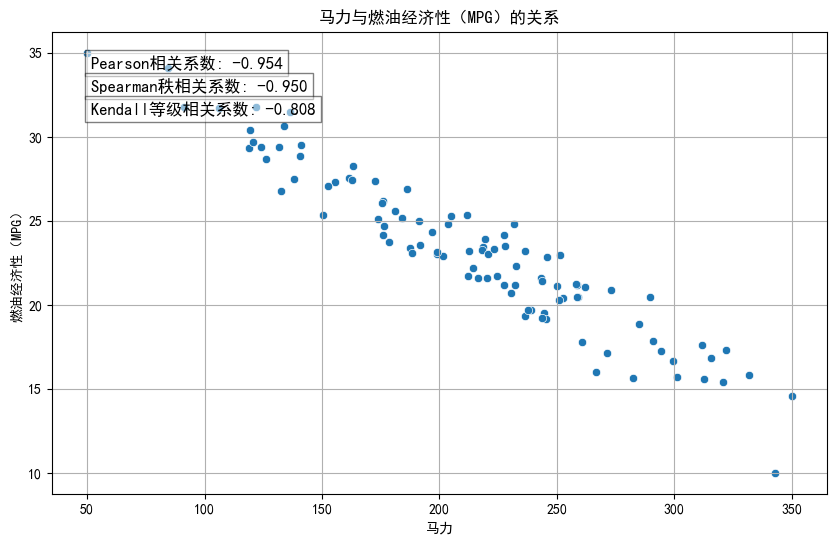

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau, pearsonr

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取数据集
data = pd.read_csv(r"F:\zhoumian\book\FuelEconomy.csv")
columns_to_analyze = ['Horse Power', 'Fuel Economy (MPG)']  # 确认列名后更新要分析的列名
data = data[columns_to_analyze].dropna()  # 缺失值处理

# 2. 计算相关系数
spearman_corr, spearman_pval = spearmanr(data['Horse Power'], data['Fuel Economy (MPG)'])
kendall_corr, kendall_pval = kendalltau(data['Horse Power'], data['Fuel Economy (MPG)'])
pearson_corr, pearson_pval = pearsonr(data['Horse Power'], data['Fuel Economy (MPG)'])

print("Pearson相关系数:", pearson_corr)  # 打印相关系数
print("Spearman秩相关系数:", spearman_corr)
print("Kendall等级相关系数:", kendall_corr)

# 3. 绘制散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Horse Power', y='Fuel Economy (MPG)', data=data)
plt.title('马力与燃油经济性（MPG）的关系')
plt.xlabel('马力')
plt.ylabel('燃油经济性（MPG）')
plt.grid(True)

# 添加相关系数到图中
plt.text(0.05, 0.95, f'Pearson相关系数: {pearson_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.90, f'Spearman秩相关系数: {spearman_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.85, f'Kendall等级相关系数: {kendall_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# 4. 保存图像为SVG格式
plt.savefig(r'F:\zhoumian\species_value_plot.svg', format='svg')

# 显示图像
plt.show()
